# Efficient VLM Inference via Visual Token Compression

**Colab/A100 analysis notebook**

This notebook is the main analysis artifact for the HPML project. It evaluates whether visual token compression improves Qwen2.5-VL inference efficiency while preserving task quality. It intentionally separates official VQA accuracy from exact-match metrics: the notebook validates the dataset schema before choosing the quality metric.

## 1. Project Goals and Hypotheses

The proposal argues that high-resolution and multi-image VLM inputs create a visual-token explosion that increases latency and GPU memory. The project is meant to validate these core hypotheses:

| ID | Hypothesis | Evidence in this notebook |
|---|---|---|
| H1 | Higher visual token counts from larger images increase baseline latency and peak GPU memory. | Baseline sweep over low / medium / high synthetic resolutions. |
| H2 | Reducing visual token retention lowers prefill latency and memory, with larger gains at higher resolution. | Matched baseline-vs-compression sweep across methods, retention ratios, and resolutions. |
| H3 | Moderate compression can preserve VQA quality, while aggressive compression degrades it. | Dataset-validated quality metric over a fixed VQA subset. |
| H4 | Importance-based pruning or token merging should offer a better quality-efficiency tradeoff than uniform fixed-ratio pruning. | Quality-latency tradeoff curves at matched retention ratios. |

Scope note: the proposal also mentions multi-image context density. This notebook focuses on single-image inputs first because the current compression wrapper and VQA evaluation path are single-image. Multi-image evaluation is listed as a limitation until implemented and validated separately.

## 2. Environment Setup

Run this on Colab with an NVIDIA A100 runtime when possible. Smaller GPUs can run the notebook with fewer samples or without the high-resolution grid point.

In [1]:
!nvidia-smi

Thu Apr 30 01:17:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             50W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"PyTorch version: {torch.__version__}")
assert torch.cuda.is_available(), "This notebook is intended to run on a CUDA GPU runtime."

CUDA available: True
Device: NVIDIA A100-SXM4-40GB
PyTorch version: 2.10.0+cu128


## 3. Clone and Install

If this notebook is already inside the repo, the clone step is skipped. In Colab, run from a fresh runtime and install the package in editable mode so notebook changes import the local source tree.

In [3]:
from pathlib import Path
import os

REPO_URL = "https://github.com/HaojingTONG/VLM-Inference.git"
if not Path("src").exists():
    os.system(f"git clone {REPO_URL}")
    os.chdir("VLM-Inference")

print("Working directory:", Path.cwd())

Working directory: /content/VLM-Inference


In [4]:
%pip install -q -r requirements.txt
%pip install -q -e .

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 77.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


### 3b. Bootstrap Notebook Helper Modules

This keeps the notebook runnable in Colab even if the cloned GitHub repo has not yet been updated with the helper modules used below.


In [ ]:
# Bootstrap notebook helper modules when running from a Colab clone that
# does not yet include the latest local source files.
from pathlib import Path

_HELPER_MODULES = {
    'src/evaluation/vqa.py': '"""VQA dataset validation and honest answer scoring.\n\nThe important distinction in this module is naming. Official VQA accuracy is\nonly valid when each evaluated question has the VQA-style set of 10 human\nanswers. Datasets that expose only ``multiple_choice_answer`` or one reference\ncan still be useful, but they should be reported as exact match instead.\n"""\n\nfrom __future__ import annotations\n\nfrom dataclasses import asdict, dataclass\nfrom typing import Any, Iterable\nimport re\n\n\n_CONTRACTIONS = {\n    "aint": "ain\'t",\n    "arent": "aren\'t",\n    "cant": "can\'t",\n    "couldve": "could\'ve",\n    "couldnt": "couldn\'t",\n    "didnt": "didn\'t",\n    "doesnt": "doesn\'t",\n    "dont": "don\'t",\n    "hadnt": "hadn\'t",\n    "hasnt": "hasn\'t",\n    "havent": "haven\'t",\n    "hed": "he\'d",\n    "hes": "he\'s",\n    "im": "i\'m",\n    "ive": "i\'ve",\n    "isnt": "isn\'t",\n    "itd": "it\'d",\n    "itll": "it\'ll",\n    "lets": "let\'s",\n    "shouldnt": "shouldn\'t",\n    "thats": "that\'s",\n    "theres": "there\'s",\n    "theyll": "they\'ll",\n    "theyre": "they\'re",\n    "wasnt": "wasn\'t",\n    "werent": "weren\'t",\n    "whats": "what\'s",\n    "wheres": "where\'s",\n    "whos": "who\'s",\n    "wont": "won\'t",\n    "wouldnt": "wouldn\'t",\n    "youd": "you\'d",\n    "youll": "you\'ll",\n    "youre": "you\'re",\n    "youve": "you\'ve",\n}\n_NUM_WORDS = {\n    "none": "0",\n    "zero": "0",\n    "one": "1",\n    "two": "2",\n    "three": "3",\n    "four": "4",\n    "five": "5",\n    "six": "6",\n    "seven": "7",\n    "eight": "8",\n    "nine": "9",\n    "ten": "10",\n}\n_ARTICLES = {"a", "an", "the"}\n_PUNCT = [\n    ";",\n    r"/",\n    "[",\n    "]",\n    \'"\',\n    "{",\n    "}",\n    "(",\n    ")",\n    "=",\n    "+",\n    "\\\\",\n    "_",\n    "-",\n    ">",\n    "<",\n    "@",\n    "`",\n    ",",\n    "?",\n    "!",\n]\n_PERIOD_STRIP = re.compile(r"(?<!\\d)(\\.)(?!\\d)")\n_COMMA_STRIP = re.compile(r"(\\d)(,)(\\d)")\n\n\n@dataclass\nclass VQASchemaReport:\n    """Summary of whether a dataset split can support a named VQA metric."""\n\n    dataset_name: str\n    n_checked: int\n    fields: list[str]\n    image_field: str | None\n    question_field: str | None\n    answer_field: str | None\n    multiple_choice_field: str | None\n    answer_count_min: int\n    answer_count_max: int\n    supports_official_vqa_accuracy: bool\n    selected_metric: str\n    issues: list[str]\n\n    def to_dict(self) -> dict[str, Any]:\n        return asdict(self)\n\n\ndef normalize_answer(answer: Any) -> str:\n    """Normalize an answer using the standard VQA text conventions."""\n    text = "" if answer is None else str(answer)\n    text = text.lower().strip()\n\n    for punct in _PUNCT:\n        if (punct + " " in text or " " + punct in text) or _COMMA_STRIP.search(text):\n            text = text.replace(punct, "")\n        else:\n            text = text.replace(punct, " ")\n    text = _PERIOD_STRIP.sub("", text)\n\n    tokens = []\n    for token in text.split():\n        token = _NUM_WORDS.get(token, token)\n        token = _CONTRACTIONS.get(token, token)\n        if token in _ARTICLES:\n            continue\n        tokens.append(token)\n    return " ".join(tokens).strip()\n\n\ndef exact_match_score(prediction: Any, reference: Any) -> float:\n    """Normalized exact match against a single reference answer."""\n    return float(normalize_answer(prediction) == normalize_answer(reference))\n\n\ndef official_vqa_score(prediction: Any, human_answers: Iterable[Any]) -> float:\n    """Compute official VQA consensus score for one prediction.\n\n    The official protocol expects 10 human answers. This function enforces that\n    contract so callers cannot silently report official VQA accuracy on a\n    dataset that only exposes one answer.\n    """\n    answers = [normalize_answer(a) for a in human_answers if a is not None]\n    if len(answers) != 10:\n        raise ValueError(\n            "official_vqa_score requires exactly 10 human answers; "\n            f"received {len(answers)}."\n        )\n\n    pred = normalize_answer(prediction)\n    per_annotator_scores = []\n    for i in range(10):\n        other_answers = answers[:i] + answers[i + 1 :]\n        matches = sum(1 for answer in other_answers if answer == pred)\n        per_annotator_scores.append(min(matches / 3.0, 1.0))\n    return sum(per_annotator_scores) / 10.0\n\n\ndef extract_human_answers(sample: dict[str, Any]) -> list[str]:\n    """Extract VQA-style human answers from common dataset schemas."""\n    answers = sample.get("answers")\n    if isinstance(answers, list):\n        if not answers:\n            return []\n        if isinstance(answers[0], dict):\n            extracted = []\n            for item in answers:\n                value = item.get("answer")\n                if value is not None:\n                    extracted.append(str(value))\n            return extracted\n        return [str(answer) for answer in answers if answer is not None]\n\n    if isinstance(answers, dict):\n        # Some datasets store {"answer": [...]} or {"text": [...]}.\n        for key in ("answer", "answers", "text"):\n            value = answers.get(key)\n            if isinstance(value, list):\n                return [str(answer) for answer in value if answer is not None]\n    return []\n\n\ndef extract_single_reference(sample: dict[str, Any]) -> str | None:\n    """Extract the best available single-reference answer for exact match."""\n    for key in ("multiple_choice_answer", "answer", "label"):\n        value = sample.get(key)\n        if isinstance(value, str) and value.strip():\n            return value\n\n    human_answers = extract_human_answers(sample)\n    if human_answers:\n        return human_answers[0]\n    return None\n\n\ndef validate_vqa_schema(\n    samples: Iterable[dict[str, Any]],\n    dataset_name: str = "unknown",\n    max_samples: int | None = None,\n) -> VQASchemaReport:\n    """Inspect samples and choose the strongest honest metric they support."""\n    checked = []\n    for i, sample in enumerate(samples):\n        if max_samples is not None and i >= max_samples:\n            break\n        checked.append(sample)\n\n    if not checked:\n        return VQASchemaReport(\n            dataset_name=dataset_name,\n            n_checked=0,\n            fields=[],\n            image_field=None,\n            question_field=None,\n            answer_field=None,\n            multiple_choice_field=None,\n            answer_count_min=0,\n            answer_count_max=0,\n            supports_official_vqa_accuracy=False,\n            selected_metric="unscored",\n            issues=["No samples were available for schema validation."],\n        )\n\n    fields = sorted({key for sample in checked for key in sample.keys()})\n    image_field = next((k for k in ("image", "image_path", "path") if k in fields), None)\n    question_field = next((k for k in ("question", "prompt") if k in fields), None)\n    multiple_choice_field = next(\n        (k for k in ("multiple_choice_answer", "answer", "label") if k in fields),\n        None,\n    )\n    answer_field = "answers" if "answers" in fields else multiple_choice_field\n\n    answer_counts = [len(extract_human_answers(sample)) for sample in checked]\n    answer_count_min = min(answer_counts) if answer_counts else 0\n    answer_count_max = max(answer_counts) if answer_counts else 0\n\n    issues = []\n    if image_field is None:\n        issues.append("No image field found; expected one of image, image_path, path.")\n    if question_field is None:\n        issues.append("No question field found; expected question or prompt.")\n\n    supports_official = (\n        image_field is not None\n        and question_field is not None\n        and bool(answer_counts)\n        and all(count == 10 for count in answer_counts)\n    )\n    if supports_official:\n        selected_metric = "official_vqa_accuracy"\n    elif any(extract_single_reference(sample) is not None for sample in checked):\n        selected_metric = (\n            "multiple_choice_exact_match"\n            if "multiple_choice_answer" in fields\n            else "single_reference_exact_match"\n        )\n        issues.append(\n            "Dataset does not expose exactly 10 human answers for every checked "\n            f"sample (observed min={answer_count_min}, max={answer_count_max}); "\n            f"using {selected_metric} instead of official VQA accuracy."\n        )\n    else:\n        selected_metric = "unscored"\n        issues.append("No usable answer references found.")\n\n    return VQASchemaReport(\n        dataset_name=dataset_name,\n        n_checked=len(checked),\n        fields=fields,\n        image_field=image_field,\n        question_field=question_field,\n        answer_field=answer_field,\n        multiple_choice_field=multiple_choice_field,\n        answer_count_min=answer_count_min,\n        answer_count_max=answer_count_max,\n        supports_official_vqa_accuracy=supports_official,\n        selected_metric=selected_metric,\n        issues=issues,\n    )\n\n\ndef score_vqa_prediction(\n    prediction: Any,\n    sample: dict[str, Any],\n    metric_name: str,\n) -> tuple[float | None, list[str] | str | None]:\n    """Score one prediction using the metric selected by schema validation."""\n    if metric_name == "official_vqa_accuracy":\n        answers = extract_human_answers(sample)\n        return official_vqa_score(prediction, answers), answers\n\n    if metric_name in {"multiple_choice_exact_match", "single_reference_exact_match"}:\n        reference = extract_single_reference(sample)\n        if reference is None:\n            return None, None\n        return exact_match_score(prediction, reference), reference\n\n    return None, None\n',
    'src/evaluation/experiments.py': '"""Reusable experiment helpers for the Colab analysis notebook."""\n\nfrom __future__ import annotations\n\nimport gc\nimport json\nimport time\nfrom pathlib import Path\nfrom typing import Any, Callable\n\nimport numpy as np\nimport pandas as pd\nimport torch\nfrom PIL import Image\nfrom datasets import load_dataset\n\nfrom src.compression import CompressedVLM, FixedRatioPruner, ImportanceBasedPruner, TokenMerger\nfrom src.utils.profiler import InferenceProfiler\nfrom .vqa import (\n    score_vqa_prediction,\n    validate_vqa_schema,\n)\n\n\nPROJECT_HYPOTHESES = [\n    {\n        "id": "H1",\n        "hypothesis": (\n            "Higher visual token counts from larger images increase latency and peak "\n            "GPU memory in the baseline VLM pipeline."\n        ),\n        "evidence": "Baseline sweep over low / medium / high image resolutions.",\n    },\n    {\n        "id": "H2",\n        "hypothesis": (\n            "Reducing visual token retention lowers prefill latency and memory, "\n            "with the largest gains expected at high resolution."\n        ),\n        "evidence": "Matched baseline-vs-compression sweep over method, retention ratio, and resolution.",\n    },\n    {\n        "id": "H3",\n        "hypothesis": (\n            "Task quality is retained at moderate compression but degrades under "\n            "aggressive token reduction."\n        ),\n        "evidence": "VQA quality metric selected by validated dataset schema.",\n    },\n    {\n        "id": "H4",\n        "hypothesis": (\n            "Importance-based pruning or token merging should dominate uniform "\n            "fixed-ratio pruning at the same retention ratio if they preserve "\n            "more informative visual tokens."\n        ),\n        "evidence": "Quality-latency tradeoff curves comparing methods at matched retention.",\n    },\n]\n\n\nCOMPRESSOR_CLASSES = {\n    "fixed_ratio": FixedRatioPruner,\n    "importance": ImportanceBasedPruner,\n    "token_merging": TokenMerger,\n}\n\n\nDEFAULT_RESOLUTIONS = {\n    "low": (448, 448),\n    "medium": (896, 896),\n    "high": (1344, 1344),\n}\n\n\ndef make_random_image(height: int, width: int, seed: int) -> Image.Image:\n    """Create a deterministic synthetic image for performance stress tests."""\n    rng = np.random.default_rng(seed)\n    arr = rng.integers(0, 255, (height, width, 3), dtype=np.uint8)\n    return Image.fromarray(arr)\n\n\ndef get_image_token_id(model, processor) -> int:\n    """Resolve Qwen image-pad token id across transformers versions."""\n    for attr in ("image_token_id", "image_token_index"):\n        value = getattr(model.config, attr, None)\n        if value is not None:\n            return int(value)\n    token_id = processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")\n    if token_id is None or token_id == processor.tokenizer.unk_token_id:\n        raise ValueError("Could not resolve Qwen image token id.")\n    return int(token_id)\n\n\ndef build_qwen_inputs(processor, device: str, image: Image.Image, prompt: str):\n    """Build chat-template inputs for one image-question pair."""\n    messages = [\n        {\n            "role": "user",\n            "content": [\n                {"type": "image", "image": image},\n                {"type": "text", "text": prompt},\n            ],\n        }\n    ]\n    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)\n    return processor(text=[text], images=[image], padding=True, return_tensors="pt").to(device)\n\n\ndef count_visual_tokens(inputs, image_token_id: int) -> int:\n    """Count visual placeholder tokens in one processed input."""\n    return int((inputs["input_ids"][0] == image_token_id).sum().item())\n\n\ndef build_compressed_wrapper(model, processor, method: str, retention_ratio: float):\n    """Create a baseline or compressed model wrapper for one grid point."""\n    if method == "none":\n        return CompressedVLM(model, processor, None)\n    compressor = COMPRESSOR_CLASSES[method](\n        {\n            "retention_ratio": retention_ratio,\n            "importance_signal": "magnitude",\n            "similarity_metric": "cosine",\n        }\n    )\n    return CompressedVLM(model, processor, compressor)\n\n\n@torch.no_grad()\ndef decode_answer(processor, model_or_wrapper, inputs, max_new_tokens: int) -> str:\n    """Generate greedily and return only newly generated text."""\n    is_compressed = (\n        isinstance(model_or_wrapper, CompressedVLM)\n        and model_or_wrapper.compressor is not None\n    )\n    if isinstance(model_or_wrapper, CompressedVLM):\n        output_ids = model_or_wrapper.generate(\n            inputs,\n            max_new_tokens=max_new_tokens,\n            do_sample=False,\n        )\n    else:\n        output_ids = model_or_wrapper.generate(\n            **inputs,\n            max_new_tokens=max_new_tokens,\n            do_sample=False,\n        )\n\n    if not is_compressed:\n        output_ids = output_ids[:, inputs["input_ids"].shape[1] :]\n    return processor.batch_decode(output_ids, skip_special_tokens=True)[0].strip()\n\n\ndef load_vqa_samples(\n    dataset_name: str,\n    split: str,\n    num_samples: int,\n    streaming: bool = False,\n):\n    """Load a bounded VQA sample list from Hugging Face Datasets."""\n    if streaming:\n        return list(load_dataset(dataset_name, split=split, streaming=True).take(num_samples))\n    split_expr = split if "[" in split else f"{split}[:{num_samples}]"\n    return list(load_dataset(dataset_name, split=split_expr))\n\n\ndef load_first_available_vqa(\n    candidates: list[dict[str, Any]],\n    num_samples: int,\n):\n    """Try dataset candidates in order and return samples plus schema report."""\n    errors = []\n    for candidate in candidates:\n        name = candidate["name"]\n        split = candidate.get("split", "validation")\n        streaming = bool(candidate.get("streaming", False))\n        try:\n            samples = load_vqa_samples(name, split, num_samples, streaming=streaming)\n            report = validate_vqa_schema(samples, dataset_name=name)\n            return samples, report\n        except Exception as exc:\n            errors.append(f"{name}: {type(exc).__name__}: {exc}")\n    raise RuntimeError("Could not load any VQA dataset candidate:\\n" + "\\n".join(errors))\n\n\ndef run_baseline_resolution_sweep(\n    model,\n    processor,\n    device: str = "cuda",\n    resolutions: dict[str, tuple[int, int]] | None = None,\n    num_samples_per_resolution: int = 3,\n    max_new_tokens: int = 64,\n    prompt: str = "Describe this image in detail.",\n    num_warmup: int = 1,\n    num_runs: int = 2,\n    seed: int = 42,\n) -> tuple[pd.DataFrame, pd.DataFrame]:\n    """Measure baseline full-token generation across input resolutions."""\n    resolutions = resolutions or DEFAULT_RESOLUTIONS\n    image_token_id = get_image_token_id(model, processor)\n    profiler = InferenceProfiler(num_warmup=num_warmup, num_runs=num_runs)\n    rows = []\n\n    for resolution, (height, width) in resolutions.items():\n        for sample_idx in range(num_samples_per_resolution):\n            image = make_random_image(height, width, seed + sample_idx)\n            inputs = build_qwen_inputs(processor, device, image, prompt)\n            visual_tokens = count_visual_tokens(inputs, image_token_id)\n\n            torch.cuda.empty_cache()\n            gc.collect()\n\n            def inference_fn():\n                with torch.no_grad():\n                    return model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)\n\n            metrics = profiler.profile(inference_fn)\n            with torch.no_grad():\n                output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)\n            generated_tokens = int(output_ids.shape[1] - inputs["input_ids"].shape[1])\n            latency_s = max(metrics["latency_ms"] / 1000.0, 1e-9)\n            rows.append(\n                {\n                    "resolution": resolution,\n                    "height": height,\n                    "width": width,\n                    "sample": sample_idx,\n                    "visual_tokens": visual_tokens,\n                    "latency_ms": metrics["latency_ms"],\n                    "tokens_per_sec": generated_tokens / latency_s,\n                    "peak_memory_mb": metrics["peak_gpu_memory_mb"],\n                    "generated_tokens": generated_tokens,\n                }\n            )\n\n    per_sample = pd.DataFrame(rows)\n    summary = (\n        per_sample.groupby(["resolution", "height", "width"], as_index=False)\n        .agg(\n            visual_tokens=("visual_tokens", "mean"),\n            latency_ms=("latency_ms", "mean"),\n            latency_std_ms=("latency_ms", "std"),\n            tokens_per_sec=("tokens_per_sec", "mean"),\n            peak_memory_mb=("peak_memory_mb", "max"),\n            generated_tokens=("generated_tokens", "mean"),\n        )\n    )\n    return per_sample, summary\n\n\ndef _time_generate(fn: Callable[[], Any], num_warmup: int, num_runs: int) -> dict[str, float]:\n    for _ in range(num_warmup):\n        fn()\n        torch.cuda.synchronize()\n    torch.cuda.reset_peak_memory_stats()\n    times = []\n    for _ in range(num_runs):\n        torch.cuda.synchronize()\n        start = time.perf_counter()\n        fn()\n        torch.cuda.synchronize()\n        times.append((time.perf_counter() - start) * 1000)\n    return {\n        "latency_ms": float(np.mean(times)),\n        "latency_std_ms": float(np.std(times)),\n        "peak_memory_mb": torch.cuda.max_memory_allocated() / (1024 ** 2),\n    }\n\n\ndef run_compression_performance_sweep(\n    model,\n    processor,\n    device: str = "cuda",\n    resolutions: dict[str, tuple[int, int]] | None = None,\n    methods: list[str] | None = None,\n    retention_ratios: list[float] | None = None,\n    num_samples_per_cell: int = 3,\n    max_new_tokens: int = 1,\n    prompt: str = "Describe this image in detail.",\n    num_warmup: int = 1,\n    num_runs: int = 2,\n    seed: int = 200,\n) -> pd.DataFrame:\n    """Measure matched baseline/compression prefill performance."""\n    resolutions = resolutions or DEFAULT_RESOLUTIONS\n    methods = methods or ["none", "fixed_ratio", "importance", "token_merging"]\n    retention_ratios = retention_ratios or [1.0, 0.75, 0.5, 0.25, 0.1]\n    image_token_id = get_image_token_id(model, processor)\n    rows = []\n\n    for resolution, (height, width) in resolutions.items():\n        inputs_list = [\n            build_qwen_inputs(\n                processor,\n                device,\n                make_random_image(height, width, seed + sample_idx),\n                prompt,\n            )\n            for sample_idx in range(num_samples_per_cell)\n        ]\n        visual_tokens_full = count_visual_tokens(inputs_list[0], image_token_id)\n\n        for method in methods:\n            ratios = [1.0] if method == "none" else [r for r in retention_ratios if r < 1.0]\n            for ratio in ratios:\n                wrapper = build_compressed_wrapper(model, processor, method, ratio)\n                per_sample = []\n                failures = []\n\n                for sample_idx, inputs in enumerate(inputs_list):\n                    torch.cuda.empty_cache()\n                    gc.collect()\n\n                    def fn():\n                        return wrapper.generate(inputs, max_new_tokens=max_new_tokens, do_sample=False)\n\n                    try:\n                        per_sample.append(_time_generate(fn, num_warmup, num_runs))\n                    except Exception as exc:\n                        failures.append(f"sample={sample_idx}: {type(exc).__name__}: {exc}")\n\n                if not per_sample:\n                    rows.append(\n                        {\n                            "resolution": resolution,\n                            "height": height,\n                            "width": width,\n                            "method": method,\n                            "retention_ratio": ratio,\n                            "visual_tokens_full": visual_tokens_full,\n                            "visual_tokens_after": None,\n                            "latency_ms": None,\n                            "latency_std_ms": None,\n                            "peak_memory_mb": None,\n                            "n_samples": 0,\n                            "failures": "; ".join(failures),\n                        }\n                    )\n                    continue\n\n                visual_tokens_after = (\n                    visual_tokens_full if method == "none" else int(round(visual_tokens_full * ratio))\n                )\n                rows.append(\n                    {\n                        "resolution": resolution,\n                        "height": height,\n                        "width": width,\n                        "method": method,\n                        "retention_ratio": ratio,\n                        "visual_tokens_full": visual_tokens_full,\n                        "visual_tokens_after": visual_tokens_after,\n                        "latency_ms": float(np.mean([m["latency_ms"] for m in per_sample])),\n                        "latency_std_ms": float(np.mean([m["latency_std_ms"] for m in per_sample])),\n                        "peak_memory_mb": float(max(m["peak_memory_mb"] for m in per_sample)),\n                        "n_samples": len(per_sample),\n                        "failures": "; ".join(failures),\n                    }\n                )\n    return pd.DataFrame(rows)\n\n\ndef run_vqa_quality_sweep(\n    model,\n    processor,\n    samples: list[dict[str, Any]],\n    schema_report,\n    device: str = "cuda",\n    methods: list[str] | None = None,\n    retention_ratios: list[float] | None = None,\n    max_new_tokens: int = 20,\n    prompt_template: str = (\n        "Answer the question with a single word or short phrase.\\n"\n        "Question: {question}\\nAnswer:"\n    ),\n) -> tuple[pd.DataFrame, pd.DataFrame]:\n    """Run quality evaluation using the metric selected by schema validation."""\n    methods = methods or ["none", "fixed_ratio", "importance", "token_merging"]\n    retention_ratios = retention_ratios or [1.0, 0.75, 0.5, 0.25, 0.1]\n    question_field = schema_report.question_field or "question"\n    image_field = schema_report.image_field or "image"\n    metric_name = schema_report.selected_metric\n\n    summary_rows = []\n    prediction_rows = []\n    for method in methods:\n        ratios = [1.0] if method == "none" else [r for r in retention_ratios if r < 1.0]\n        for ratio in ratios:\n            wrapper = build_compressed_wrapper(model, processor, method, ratio)\n            scores = []\n            start = time.perf_counter()\n\n            for sample_idx, sample in enumerate(samples):\n                question = sample[question_field]\n                image = sample[image_field]\n                prompt = prompt_template.format(question=question)\n                inputs = build_qwen_inputs(processor, device, image, prompt)\n\n                try:\n                    prediction = decode_answer(processor, wrapper, inputs, max_new_tokens)\n                    score, reference = score_vqa_prediction(prediction, sample, metric_name)\n                except Exception as exc:\n                    prediction_rows.append(\n                        {\n                            "sample": sample_idx,\n                            "method": method,\n                            "retention_ratio": ratio,\n                            "question": question,\n                            "prediction": None,\n                            "reference": None,\n                            "score": None,\n                            "error": f"{type(exc).__name__}: {exc}",\n                        }\n                    )\n                    continue\n\n                if score is not None:\n                    scores.append(score)\n                prediction_rows.append(\n                    {\n                        "sample": sample_idx,\n                        "method": method,\n                        "retention_ratio": ratio,\n                        "question": question,\n                        "prediction": prediction,\n                        "reference": json.dumps(reference) if isinstance(reference, list) else reference,\n                        "score": score,\n                        "error": None,\n                    }\n                )\n\n            torch.cuda.empty_cache()\n            gc.collect()\n            summary_rows.append(\n                {\n                    "method": method,\n                    "retention_ratio": ratio,\n                    "metric": metric_name,\n                    "score": float(np.mean(scores)) if scores else None,\n                    "n_scored": len(scores),\n                    "n_total": len(samples),\n                    "eval_seconds": time.perf_counter() - start,\n                }\n            )\n\n    return pd.DataFrame(summary_rows), pd.DataFrame(prediction_rows)\n\n\ndef bootstrap_quality_ci(\n    df_predictions: pd.DataFrame,\n    n_bootstrap: int = 1000,\n    ci: float = 0.95,\n    seed: int = 123,\n) -> pd.DataFrame:\n    """Bootstrap confidence intervals over per-question quality scores."""\n    valid = df_predictions.dropna(subset=["score"]).copy()\n    if valid.empty:\n        return pd.DataFrame(\n            columns=[\n                "method",\n                "retention_ratio",\n                "mean_score",\n                "ci_low",\n                "ci_high",\n                "n_scored",\n            ]\n        )\n\n    rng = np.random.default_rng(seed)\n    alpha = 1.0 - ci\n    rows = []\n    for (method, ratio), group in valid.groupby(["method", "retention_ratio"]):\n        scores = group["score"].to_numpy(dtype=float)\n        boot_means = []\n        for _ in range(n_bootstrap):\n            sample = rng.choice(scores, size=len(scores), replace=True)\n            boot_means.append(float(sample.mean()))\n        rows.append(\n            {\n                "method": method,\n                "retention_ratio": ratio,\n                "mean_score": float(scores.mean()),\n                "ci_low": float(np.quantile(boot_means, alpha / 2)),\n                "ci_high": float(np.quantile(boot_means, 1 - alpha / 2)),\n                "n_scored": len(scores),\n            }\n        )\n    return pd.DataFrame(rows).sort_values(["method", "retention_ratio"]).reset_index(drop=True)\n\n\ndef run_max_batch_size_probe(\n    model,\n    processor,\n    device: str = "cuda",\n    resolution_name: str = "medium",\n    resolution: tuple[int, int] = (896, 896),\n    methods: list[str] | None = None,\n    retention_ratios: list[float] | None = None,\n    max_batch_size: int = 8,\n    max_new_tokens: int = 8,\n    prompt: str = "Describe this image briefly.",\n    seed: int = 900,\n) -> pd.DataFrame:\n    """Find max feasible batch size before OOM for selected configurations."""\n    methods = methods or ["none", "token_merging"]\n    retention_ratios = retention_ratios or [1.0, 0.5]\n    height, width = resolution\n    image = make_random_image(height, width, seed)\n    rows = []\n\n    for method in methods:\n        ratios = [1.0] if method == "none" else [r for r in retention_ratios if r < 1.0]\n        for ratio in ratios:\n            wrapper = build_compressed_wrapper(model, processor, method, ratio)\n\n            def batched_inference(batch_size):\n                images = [image] * batch_size\n                messages_batch = [\n                    [\n                        {\n                            "role": "user",\n                            "content": [\n                                {"type": "image", "image": img},\n                                {"type": "text", "text": prompt},\n                            ],\n                        }\n                    ]\n                    for img in images\n                ]\n                texts = [\n                    processor.apply_chat_template(\n                        messages,\n                        tokenize=False,\n                        add_generation_prompt=True,\n                    )\n                    for messages in messages_batch\n                ]\n                inputs = processor(\n                    text=texts,\n                    images=images,\n                    padding=True,\n                    return_tensors="pt",\n                ).to(device)\n                return wrapper.generate(\n                    inputs,\n                    max_new_tokens=max_new_tokens,\n                    do_sample=False,\n                )\n\n            try:\n                max_bs = InferenceProfiler.find_max_batch_size(\n                    lambda batch_size: batched_inference(batch_size),\n                    min_bs=1,\n                    max_bs=max_batch_size,\n                )\n                error = ""\n            except Exception as exc:\n                max_bs = None\n                error = f"{type(exc).__name__}: {exc}"\n            rows.append(\n                {\n                    "resolution": resolution_name,\n                    "height": height,\n                    "width": width,\n                    "method": method,\n                    "retention_ratio": ratio,\n                    "max_batch_size": max_bs,\n                    "probe_max_batch_size": max_batch_size,\n                    "max_new_tokens": max_new_tokens,\n                    "error": error,\n                }\n            )\n            torch.cuda.empty_cache()\n            gc.collect()\n\n    return pd.DataFrame(rows)\n\n\ndef save_results(output_dir: str | Path, **frames: pd.DataFrame) -> dict[str, str]:\n    """Save DataFrames to CSV and JSON records for reproducible analysis."""\n    path = Path(output_dir)\n    path.mkdir(parents=True, exist_ok=True)\n    saved = {}\n    for name, frame in frames.items():\n        csv_path = path / f"{name}.csv"\n        json_path = path / f"{name}.json"\n        frame.to_csv(csv_path, index=False)\n        frame.to_json(json_path, orient="records", indent=2)\n        saved[f"{name}_csv"] = str(csv_path)\n        saved[f"{name}_json"] = str(json_path)\n    return saved\n',
    'src/evaluation/plots.py': '"""Plot helpers for the visual-token compression notebook."""\n\nfrom pathlib import Path\n\nimport matplotlib.pyplot as plt\nimport pandas as pd\n\n\ndef _save(fig, output_dir, filename):\n    path = Path(output_dir)\n    path.mkdir(parents=True, exist_ok=True)\n    fig.savefig(path / filename, dpi=160, bbox_inches="tight")\n\n\ndef plot_quality_vs_compression(df_quality: pd.DataFrame, metric_label: str, output_dir="results"):\n    """Plot task quality as token retention changes."""\n    fig, ax = plt.subplots(figsize=(8, 5))\n    baseline = df_quality[df_quality["method"] == "none"]\n    if not baseline.empty:\n        baseline_score = baseline["score"].mean()\n        ax.axhline(\n            baseline_score,\n            color="black",\n            linestyle="--",\n            alpha=0.6,\n            label=f"baseline ({baseline_score:.3f})",\n        )\n\n    for method, group in df_quality[df_quality["method"] != "none"].groupby("method"):\n        group = group.sort_values("retention_ratio")\n        ax.plot(group["retention_ratio"], group["score"], marker="o", linewidth=2, label=method)\n\n    ax.set_xlabel("Visual token retention ratio")\n    ax.set_ylabel(metric_label)\n    ax.set_title(f"{metric_label} vs compression")\n    ax.invert_xaxis()\n    ax.grid(alpha=0.3)\n    ax.legend(fontsize=8)\n    fig.tight_layout()\n    _save(fig, output_dir, "quality_vs_compression.png")\n    return fig\n\n\ndef plot_quality_ci_vs_compression(\n    df_quality_ci: pd.DataFrame,\n    metric_label: str,\n    output_dir="results",\n):\n    """Plot task quality with bootstrap confidence intervals."""\n    fig, ax = plt.subplots(figsize=(8, 5))\n    baseline = df_quality_ci[df_quality_ci["method"] == "none"]\n    if not baseline.empty:\n        row = baseline.iloc[0]\n        ax.axhline(\n            row["mean_score"],\n            color="black",\n            linestyle="--",\n            alpha=0.6,\n            label=f"baseline ({row[\'mean_score\']:.3f})",\n        )\n        ax.axhspan(row["ci_low"], row["ci_high"], color="black", alpha=0.08)\n\n    for method, group in df_quality_ci[df_quality_ci["method"] != "none"].groupby("method"):\n        group = group.sort_values("retention_ratio")\n        yerr = [\n            group["mean_score"] - group["ci_low"],\n            group["ci_high"] - group["mean_score"],\n        ]\n        ax.errorbar(\n            group["retention_ratio"],\n            group["mean_score"],\n            yerr=yerr,\n            marker="o",\n            capsize=3,\n            linewidth=2,\n            label=method,\n        )\n\n    ax.set_xlabel("Visual token retention ratio")\n    ax.set_ylabel(metric_label)\n    ax.set_title(f"{metric_label} vs compression with bootstrap CI")\n    ax.invert_xaxis()\n    ax.grid(alpha=0.3)\n    ax.legend(fontsize=8)\n    fig.tight_layout()\n    _save(fig, output_dir, "quality_ci_vs_compression.png")\n    return fig\n\n\ndef plot_latency_vs_compression(df_perf: pd.DataFrame, output_dir="results"):\n    """Plot latency as token retention changes for each resolution."""\n    resolutions = [r for r in ["low", "medium", "high"] if r in set(df_perf["resolution"])]\n    if not resolutions:\n        resolutions = sorted(df_perf["resolution"].dropna().unique())\n    fig, axes = plt.subplots(1, len(resolutions), figsize=(5 * len(resolutions), 4), squeeze=False)\n\n    for ax, resolution in zip(axes[0], resolutions):\n        sub = df_perf[df_perf["resolution"] == resolution]\n        baseline = sub[sub["method"] == "none"]["latency_ms"].mean()\n        if pd.notna(baseline):\n            ax.axhline(baseline, color="black", linestyle="--", alpha=0.6, label=f"baseline ({baseline:.0f} ms)")\n        for method, group in sub[sub["method"] != "none"].groupby("method"):\n            group = group.sort_values("retention_ratio")\n            yerr = group["latency_std_ms"] if "latency_std_ms" in group else None\n            ax.errorbar(group["retention_ratio"], group["latency_ms"], yerr=yerr, marker="o", capsize=3, label=method)\n        ax.set_title(f"{resolution} resolution")\n        ax.set_xlabel("Visual token retention ratio")\n        ax.set_ylabel("Latency (ms)")\n        ax.invert_xaxis()\n        ax.grid(alpha=0.3)\n        ax.legend(fontsize=8)\n\n    fig.suptitle("Latency vs compression")\n    fig.tight_layout()\n    _save(fig, output_dir, "latency_vs_compression.png")\n    return fig\n\n\ndef plot_memory_vs_compression(df_perf: pd.DataFrame, output_dir="results"):\n    """Plot peak GPU memory as token retention changes."""\n    fig, ax = plt.subplots(figsize=(8, 5))\n    for (resolution, method), group in df_perf.groupby(["resolution", "method"]):\n        group = group.sort_values("retention_ratio")\n        label = f"{resolution}/{method}"\n        ax.plot(group["retention_ratio"], group["peak_memory_mb"], marker="o", linewidth=1.5, label=label)\n    ax.set_xlabel("Visual token retention ratio")\n    ax.set_ylabel("Peak GPU memory (MB)")\n    ax.set_title("Memory vs compression")\n    ax.invert_xaxis()\n    ax.grid(alpha=0.3)\n    ax.legend(fontsize=7, ncol=2)\n    fig.tight_layout()\n    _save(fig, output_dir, "memory_vs_compression.png")\n    return fig\n\n\ndef plot_tradeoff(\n    df_quality: pd.DataFrame,\n    df_perf: pd.DataFrame,\n    metric_label: str,\n    resolution: str = "medium",\n    output_dir="results",\n):\n    """Plot quality against latency for matching method / ratio settings."""\n    perf = (\n        df_perf[df_perf["resolution"] == resolution]\n        .groupby(["method", "retention_ratio"], as_index=False)\n        .agg(latency_ms=("latency_ms", "mean"), peak_memory_mb=("peak_memory_mb", "max"))\n    )\n    merged = df_quality.merge(perf, on=["method", "retention_ratio"], how="inner")\n\n    fig, ax = plt.subplots(figsize=(7, 5))\n    for method, group in merged.groupby("method"):\n        group = group.sort_values("retention_ratio")\n        ax.plot(group["latency_ms"], group["score"], marker="o", linewidth=1.8, label=method)\n        for _, row in group.iterrows():\n            ax.annotate(\n                f"{row[\'retention_ratio\']:.2f}",\n                (row["latency_ms"], row["score"]),\n                fontsize=7,\n                xytext=(3, 3),\n                textcoords="offset points",\n            )\n    ax.set_xlabel(f"Latency (ms, {resolution} resolution)")\n    ax.set_ylabel(metric_label)\n    ax.set_title("Quality-latency tradeoff")\n    ax.grid(alpha=0.3)\n    ax.legend(fontsize=8)\n    fig.tight_layout()\n    _save(fig, output_dir, "quality_latency_tradeoff.png")\n    return fig\n',
}

for rel_path, content in _HELPER_MODULES.items():
    path = Path(rel_path)
    path.parent.mkdir(parents=True, exist_ok=True)
    current = path.read_text() if path.exists() else ""
    if current != content:
        path.write_text(content)
        print(f"Wrote helper module: {rel_path}")
    else:
        print(f"Helper module already current: {rel_path}")


## 4. Imports and Experiment Configuration

The sample counts below are conservative enough for iteration. For final A100 runs, increase `NUM_VQA_SAMPLES`, `NUM_SAMPLES_PER_RESOLUTION`, and `NUM_SAMPLES_PER_CELL` after the first end-to-end pass succeeds.

In [6]:
import gc
import json
from pathlib import Path

import pandas as pd
import torch
import yaml
from IPython.display import display

from src.models import load_model
from src.evaluation.experiments import (
    DEFAULT_RESOLUTIONS,
    PROJECT_HYPOTHESES,
    load_vqa_samples,
    load_first_available_vqa,
    run_baseline_resolution_sweep,
    run_compression_performance_sweep,
    run_vqa_quality_sweep,
    bootstrap_quality_ci,
    run_max_batch_size_probe,
    save_results,
)
from src.evaluation.vqa import validate_vqa_schema
from src.evaluation.plots import (
    plot_quality_vs_compression,
    plot_quality_ci_vs_compression,
    plot_latency_vs_compression,
    plot_memory_vs_compression,
    plot_tradeoff,
)

OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(exist_ok=True)

# A100-friendly defaults. Reduce these for quick smoke tests.
NUM_VQA_SAMPLES = 50
NUM_SAMPLES_PER_RESOLUTION = 3
NUM_SAMPLES_PER_CELL = 3
BASELINE_MAX_NEW_TOKENS = 64
PREFILL_MAX_NEW_TOKENS = 1
VQA_MAX_NEW_TOKENS = 20
NUM_WARMUP = 1
NUM_RUNS = 2
N_BOOTSTRAP = 1000
MAX_BATCH_PROBE = 8

METHODS = ["none", "fixed_ratio", "importance", "token_merging"]
RETENTION_RATIOS = [1.0, 0.75, 0.5, 0.25, 0.1]
RESOLUTIONS = DEFAULT_RESOLUTIONS

display(pd.DataFrame(PROJECT_HYPOTHESES))

,id,hypothesis,evidence
0,H1,Higher visual token counts from larger images ...,Baseline sweep over low / medium / high image ...
1,H2,Reducing visual token retention lowers prefill...,Matched baseline-vs-compression sweep over met...
2,H3,Task quality is retained at moderate compressi...,VQA quality metric selected by validated datas...
3,H4,Importance-based pruning or token merging shou...,Quality-latency tradeoff curves comparing meth...


## 5. Load Qwen2.5-VL

The proposal names Qwen2.5-VL as the primary model because dynamic resolution creates a useful stress test for visual-token compression. This notebook uses the 3B instruct model by default for Colab practicality; change to 7B if your A100 runtime has enough headroom.

In [7]:
with open("configs/default.yaml") as f:
    config = yaml.safe_load(f)

config["model"]["name"] = "Qwen/Qwen2.5-VL-3B-Instruct"
config["model"]["dtype"] = "float16"
config["model"]["device"] = "cuda"
config["model"]["max_new_tokens"] = BASELINE_MAX_NEW_TOKENS

print(config["model"])
model, processor = load_model(config)
model.eval()
print("Model loaded.")
print(f"Peak GPU memory after load: {torch.cuda.max_memory_allocated()/1024**3:.2f} GB")

{'name': 'Qwen/Qwen2.5-VL-3B-Instruct', 'dtype': 'float16', 'device': 'cuda', 'max_new_tokens': 64}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Model loaded.
Peak GPU memory after load: 6.99 GB


## 6. VQA Dataset Schema Validation

Official VQA accuracy requires 10 human answers per question. The previous notebook used `merve/vqav2-small` and called the result official VQA accuracy, but that dataset exposes only `multiple_choice_answer`; it supports exact match, not official VQA consensus scoring.

This section audits candidate datasets and then selects the strongest honest metric available. `lmms-lab/VQAv2` is tried first because its validation split exposes `answers` lists of length 10. If it is unavailable, the notebook falls back to `merve/vqav2-small` and clearly reports `multiple_choice_exact_match`.

In [8]:
AUDIT_CANDIDATES = [
    {"name": "merve/vqav2-small", "split": "validation", "streaming": False},
    {"name": "lmms-lab/VQAv2", "split": "validation", "streaming": True},
]

audit_rows = []
for candidate in AUDIT_CANDIDATES:
    try:
        samples = load_vqa_samples(
            candidate["name"],
            candidate["split"],
            num_samples=min(10, NUM_VQA_SAMPLES),
            streaming=candidate.get("streaming", False),
        )
        report = validate_vqa_schema(samples, dataset_name=candidate["name"])
        audit_rows.append(report.to_dict())
    except Exception as exc:
        audit_rows.append({
            "dataset_name": candidate["name"],
            "n_checked": 0,
            "supports_official_vqa_accuracy": False,
            "selected_metric": "unavailable",
            "issues": [f"{type(exc).__name__}: {exc}"],
        })

df_schema_audit = pd.DataFrame(audit_rows)
display(df_schema_audit[[
    "dataset_name",
    "n_checked",
    "fields",
    "answer_count_min",
    "answer_count_max",
    "supports_official_vqa_accuracy",
    "selected_metric",
    "issues",
]])

df_schema_audit.to_csv(OUTPUT_DIR / "dataset_schema_audit.csv", index=False)
df_schema_audit.to_json(OUTPUT_DIR / "dataset_schema_audit.json", orient="records", indent=2)

README.md:   0%|          | 0.00/403 [00:00<?, ?B/s]

data/validation-00000-of-00007.parquet:   0%|          | 0.00/484M [00:00<?, ?B/s]

data/validation-00001-of-00007.parquet:   0%|          | 0.00/486M [00:00<?, ?B/s]

data/validation-00002-of-00007.parquet:   0%|          | 0.00/483M [00:00<?, ?B/s]

data/validation-00003-of-00007.parquet:   0%|          | 0.00/486M [00:00<?, ?B/s]

...

Resolving data files:   0%|          | 0/143 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/68 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/143 [00:00<?, ?it/s]

,dataset_name,n_checked,fields,answer_count_min,answer_count_max,supports_official_vqa_accuracy,selected_metric,issues
0,merve/vqav2-small,10,"[image, multiple_choice_answer, question]",0,0,False,multiple_choice_exact_match,[Dataset does not expose exactly 10 human answ...
1,lmms-lab/VQAv2,10,"[answer_type, answers, image, image_id, multip...",10,10,True,official_vqa_accuracy,[]


In [9]:
VQA_CANDIDATES = [
    {"name": "lmms-lab/VQAv2", "split": "validation", "streaming": True},
    {"name": "merve/vqav2-small", "split": "validation", "streaming": False},
]

vqa_samples, schema_report = load_first_available_vqa(VQA_CANDIDATES, NUM_VQA_SAMPLES)
schema = schema_report.to_dict()
print(json.dumps(schema, indent=2))

metric_name = schema_report.selected_metric
metric_label = {
    "official_vqa_accuracy": "Official VQA accuracy",
    "multiple_choice_exact_match": "Multiple-choice exact match",
    "single_reference_exact_match": "Single-reference exact match",
}.get(metric_name, metric_name)

if metric_name != "official_vqa_accuracy":
    print(f"Using {metric_label}. Do not report this as official VQA accuracy.")
else:
    print("Dataset supports official VQA accuracy: 10 human answers were found for every checked sample.")

Resolving data files:   0%|          | 0/68 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/143 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/68 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/143 [00:00<?, ?it/s]

{
  "dataset_name": "lmms-lab/VQAv2",
  "n_checked": 50,
  "fields": [
    "answer_type",
    "answers",
    "image",
    "image_id",
    "multiple_choice_answer",
    "question",
    "question_id",
    "question_type"
  ],
  "image_field": "image",
  "question_field": "question",
  "answer_field": "answers",
  "multiple_choice_field": "multiple_choice_answer",
  "answer_count_min": 10,
  "answer_count_max": 10,
  "supports_official_vqa_accuracy": true,
  "selected_metric": "official_vqa_accuracy",
  "issues": []
}
Dataset supports official VQA accuracy: 10 human answers were found for every checked sample.


## 7. Corrected Quality Evaluation

This section evaluates answer quality over a fixed VQA subset. The metric name comes directly from the schema validator above. If the selected dataset does not support official VQA accuracy, all tables and plots use exact-match terminology instead.

In [10]:
df_quality, df_predictions = run_vqa_quality_sweep(
    model=model,
    processor=processor,
    samples=vqa_samples,
    schema_report=schema_report,
    device="cuda",
    methods=METHODS,
    retention_ratios=RETENTION_RATIOS,
    max_new_tokens=VQA_MAX_NEW_TOKENS,
)

display(df_quality)
display(df_predictions.head(10))

save_results(
    OUTPUT_DIR,
    quality_summary=df_quality,
    quality_predictions=df_predictions,
)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


,method,retention_ratio,metric,score,n_scored,n_total,eval_seconds
0,none,1.00,official_vqa_accuracy,0.794,50,50,13.869347
1,fixed_ratio,0.75,official_vqa_accuracy,0.822,50,50,11.703071
2,fixed_ratio,0.50,official_vqa_accuracy,0.836,50,50,11.784329
3,fixed_ratio,0.25,official_vqa_accuracy,0.808,50,50,11.556262
4,fixed_ratio,0.10,official_vqa_accuracy,0.656,50,50,11.203720
5,importance,0.75,official_vqa_accuracy,0.808,50,50,11.744280
6,importance,0.50,official_vqa_accuracy,0.754,50,50,11.466601
7,importance,0.25,official_vqa_accuracy,0.662,50,50,11.380847
8,importance,0.10,official_vqa_accuracy,0.460,50,50,13.051921
9,token_merging,0.75,official_vqa_accuracy,0.834,50,50,11.642238


,sample,method,retention_ratio,question,prediction,reference,score,error
0,0,none,1.0,Where is he looking?,down,"[""down"", ""down"", ""at table"", ""skateboard"", ""do...",1.0,None
1,1,none,1.0,What are the people in the background doing?,watching,"[""spectating"", ""watching"", ""watching"", ""watchi...",1.0,None
2,2,none,1.0,What is he on top of?,skateboard,"[""table"", ""table"", ""table"", ""picnic table"", ""p...",0.3,None
3,3,none,1.0,What website copyrighted the picture?,Foodiebaker.com,"[""foodiebakercom"", ""foodiebakercom"", ""foodieba...",1.0,None
4,4,none,1.0,Is this a creamy soup?,no,"[""no"", ""no"", ""no"", ""no"", ""no"", ""no"", ""no"", ""no...",1.0,None
5,5,none,1.0,Is this rice noodle soup?,yes,"[""yes"", ""yes"", ""yes"", ""yes"", ""yes"", ""yes"", ""ye...",1.0,None
6,6,none,1.0,What is to the right of the soup?,spoon,"[""chopsticks"", ""chopsticks"", ""chopsticks"", ""ch...",0.0,None
7,7,none,1.0,What is the man doing in the street?,crossing,"[""crossing it"", ""walking"", ""walking"", ""crossin...",0.9,None
8,8,none,1.0,How many photo's can you see?,1,"[""1"", ""1"", ""4"", ""4"", ""4"", ""1"", ""1"", ""4"", ""1"", ...",1.0,None
9,9,none,1.0,What does the truck on the left sell?,ice cream,"[""ice cream"", ""ice cream"", ""ice cream"", ""ice c...",1.0,None


{'quality_summary_csv': 'results/quality_summary.csv',
 'quality_summary_json': 'results/quality_summary.json',
 'quality_predictions_csv': 'results/quality_predictions.csv',
 'quality_predictions_json': 'results/quality_predictions.json'}

### 7b. Quality Uncertainty

The VQA subset is intentionally bounded for Colab runtime, so small differences in quality should not be over-interpreted. This bootstrap interval estimates uncertainty over the evaluated questions; overlapping intervals are a warning against claiming one method is better.

In [ ]:
df_quality_ci = bootstrap_quality_ci(
    df_predictions,
    n_bootstrap=N_BOOTSTRAP,
    ci=0.95,
    seed=123,
)
display(df_quality_ci)
save_results(OUTPUT_DIR, quality_bootstrap_ci=df_quality_ci)

## 8. Baseline Full-Token Performance

This sweep validates H1 by measuring the uncompressed model at different input resolutions. It uses deterministic random images so the visual-token count and input scale are controlled. The quality evaluation above uses real VQA images; this performance sweep isolates token-count effects.

In [11]:
df_baseline_samples, df_baseline_summary = run_baseline_resolution_sweep(
    model=model,
    processor=processor,
    device="cuda",
    resolutions=RESOLUTIONS,
    num_samples_per_resolution=NUM_SAMPLES_PER_RESOLUTION,
    max_new_tokens=BASELINE_MAX_NEW_TOKENS,
    num_warmup=NUM_WARMUP,
    num_runs=NUM_RUNS,
)

display(df_baseline_summary)
save_results(
    OUTPUT_DIR,
    baseline_per_sample=df_baseline_samples,
    baseline_summary=df_baseline_summary,
)

,resolution,height,width,visual_tokens,latency_ms,latency_std_ms,tokens_per_sec,peak_memory_mb,generated_tokens
0,high,1344,1344,2304.0,3538.276629,10.079450,18.087999,7642.168457,64.0
1,low,448,448,256.0,3231.295351,11.019915,19.806452,7222.949219,64.0
2,medium,896,896,1024.0,3242.088529,192.262921,19.126199,7377.449219,62.0


{'baseline_per_sample_csv': 'results/baseline_per_sample.csv',
 'baseline_per_sample_json': 'results/baseline_per_sample.json',
 'baseline_summary_csv': 'results/baseline_summary.csv',
 'baseline_summary_json': 'results/baseline_summary.json'}

## 9. Fair Baseline vs Compression Performance

This sweep compares every compression method against the no-compression baseline on the same synthetic inputs, with the same prompt and fixed generation length. `max_new_tokens=1` intentionally isolates prefill latency, where visual token count should matter most; long text decoding can otherwise hide the compression effect.

In [12]:
df_perf = run_compression_performance_sweep(
    model=model,
    processor=processor,
    device="cuda",
    resolutions=RESOLUTIONS,
    methods=METHODS,
    retention_ratios=RETENTION_RATIOS,
    num_samples_per_cell=NUM_SAMPLES_PER_CELL,
    max_new_tokens=PREFILL_MAX_NEW_TOKENS,
    num_warmup=NUM_WARMUP,
    num_runs=NUM_RUNS,
)

display(df_perf)
save_results(OUTPUT_DIR, compression_performance=df_perf)

,resolution,height,width,method,retention_ratio,visual_tokens_full,visual_tokens_after,latency_ms,latency_std_ms,peak_memory_mb,n_samples,failures
0,low,448,448,none,1.00,256,256,117.399211,0.500486,7231.332031,3,
1,low,448,448,fixed_ratio,0.75,256,192,124.742682,1.121961,7230.632812,3,
2,low,448,448,fixed_ratio,0.50,256,128,124.089175,0.303897,7230.632812,3,
3,low,448,448,fixed_ratio,0.25,256,64,122.955385,0.373222,7230.632812,3,
4,low,448,448,fixed_ratio,0.10,256,26,123.836027,1.050451,7230.632812,3,
5,low,448,448,importance,0.75,256,192,124.325240,0.724982,7230.632812,3,
6,low,448,448,importance,0.50,256,128,123.839981,0.438639,7230.632812,3,
7,low,448,448,importance,0.25,256,64,122.979265,0.280361,7230.632812,3,
8,low,448,448,importance,0.10,256,26,124.964611,0.464660,7230.632812,3,
9,low,448,448,token_merging,0.75,256,192,124.339487,0.531647,7230.632812,3,


{'compression_performance_csv': 'results/compression_performance.csv',
 'compression_performance_json': 'results/compression_performance.json'}

### 9b. Max Feasible Batch Size Probe

The proposal asks for maximum feasible batch size before OOM. This probe is deliberately small and bounded (`MAX_BATCH_PROBE`) so it is safe on Colab. It compares the baseline against representative compressed configurations at medium resolution; increase the cap for a final A100 run if time allows.

In [ ]:
df_batch_probe = run_max_batch_size_probe(
    model=model,
    processor=processor,
    device="cuda",
    resolution_name="medium",
    resolution=RESOLUTIONS["medium"],
    methods=["none", "fixed_ratio", "importance", "token_merging"],
    retention_ratios=[1.0, 0.5],
    max_batch_size=MAX_BATCH_PROBE,
    max_new_tokens=8,
)

display(df_batch_probe)
save_results(OUTPUT_DIR, max_batch_size_probe=df_batch_probe)

## 10. Plots

The figures below are saved into `results/` and use the metric selected by schema validation. They cover quality vs compression, latency vs compression, memory vs compression, and the quality-latency tradeoff.

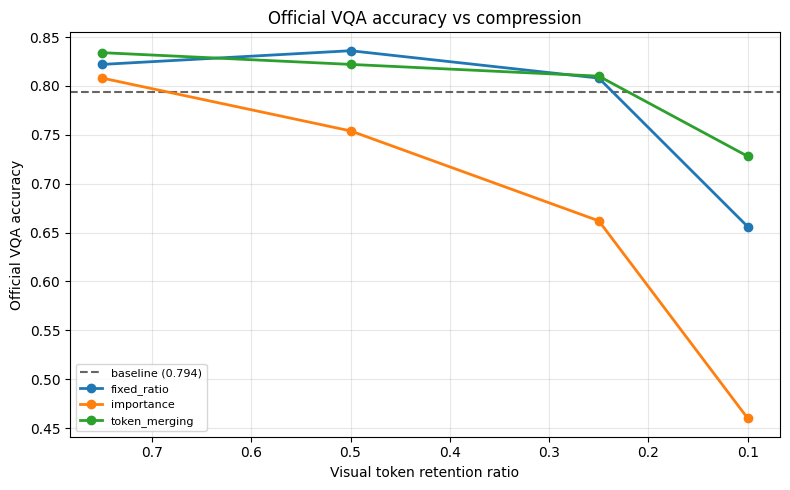

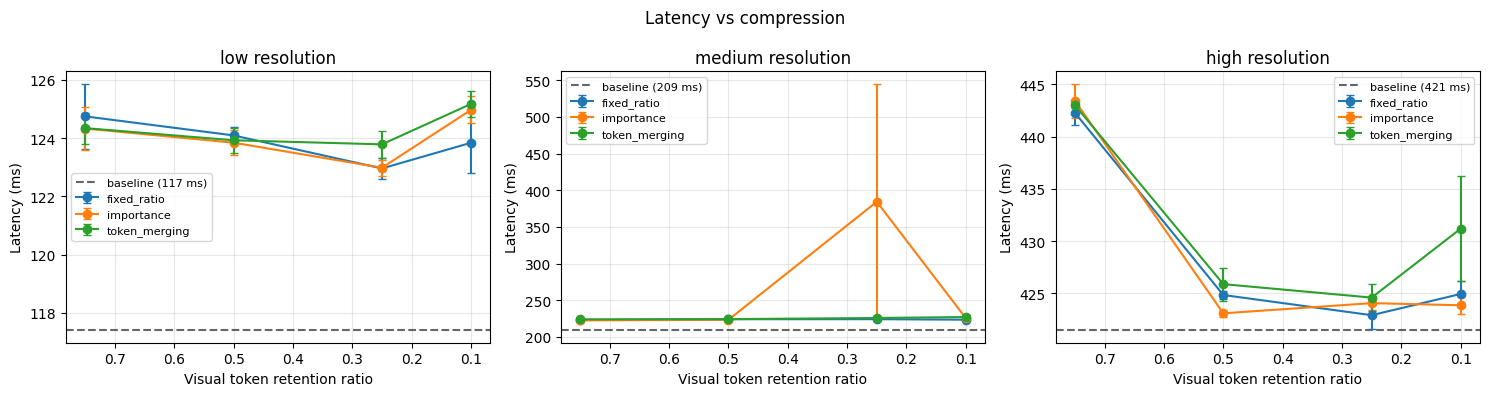

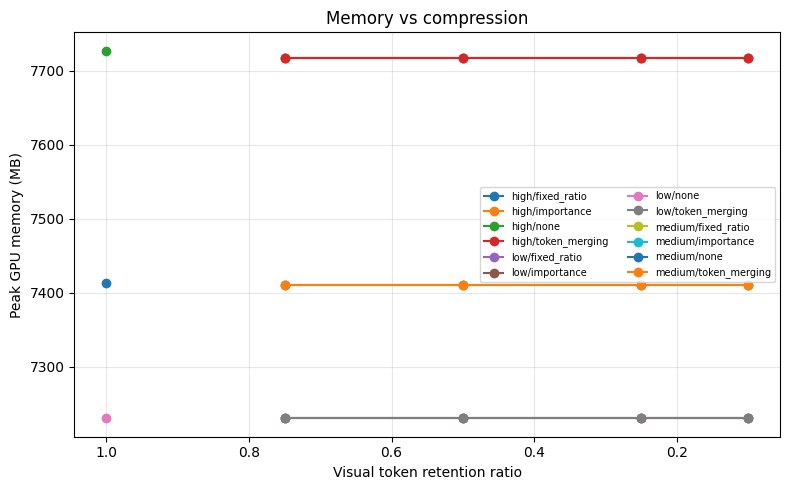

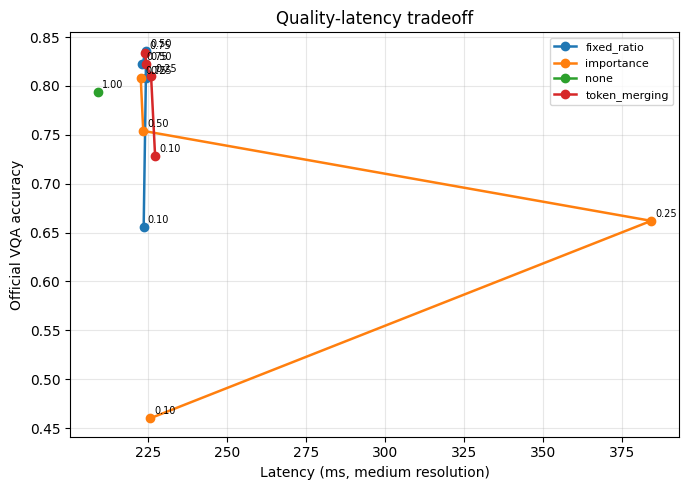

In [13]:
fig_quality = plot_quality_vs_compression(df_quality.dropna(subset=["score"]), metric_label, OUTPUT_DIR)
if "df_quality_ci" in globals() and not df_quality_ci.empty:
    fig_quality_ci = plot_quality_ci_vs_compression(df_quality_ci, metric_label, OUTPUT_DIR)
fig_latency = plot_latency_vs_compression(df_perf.dropna(subset=["latency_ms"]), OUTPUT_DIR)
fig_memory = plot_memory_vs_compression(df_perf.dropna(subset=["peak_memory_mb"]), OUTPUT_DIR)
fig_tradeoff = plot_tradeoff(
    df_quality.dropna(subset=["score"]),
    df_perf.dropna(subset=["latency_ms"]),
    metric_label,
    resolution="medium",
    output_dir=OUTPUT_DIR,
)

## 11. Final Findings and Limitations

Run the cell below after all sweeps finish. It prints a short, data-grounded summary and avoids claiming official VQA accuracy unless the dataset schema validated that metric.

In [ ]:
def summarize_findings(df_quality, df_perf, schema_report, df_quality_ci=None, df_batch_probe=None):
    lines = []
    metric_label_local = {
        "official_vqa_accuracy": "official VQA accuracy",
        "multiple_choice_exact_match": "multiple-choice exact match",
        "single_reference_exact_match": "single-reference exact match",
    }.get(schema_report.selected_metric, schema_report.selected_metric)

    lines.append(f"Quality metric used: {metric_label_local}.")
    if schema_report.selected_metric != "official_vqa_accuracy":
        lines.append("Official VQA accuracy was not reported because the selected dataset schema did not provide 10 human answers per question.")

    if not df_quality.empty and df_quality["score"].notna().any():
        base = df_quality[df_quality["method"] == "none"]["score"].mean()
        lines.append(f"Baseline quality: {base:.3f}.")
        best_compressed = df_quality[df_quality["method"] != "none"].sort_values("score", ascending=False).head(1)
        if not best_compressed.empty:
            row = best_compressed.iloc[0]
            lines.append(f"Best compressed quality: {row['score']:.3f} ({row['method']} at retention {row['retention_ratio']:.2f}).")

        if df_quality_ci is not None and not df_quality_ci.empty:
            base_ci = df_quality_ci[df_quality_ci["method"] == "none"]
            if not base_ci.empty:
                row = base_ci.iloc[0]
                lines.append(f"Baseline 95% bootstrap CI: [{row['ci_low']:.3f}, {row['ci_high']:.3f}] over {int(row['n_scored'])} questions.")
            lines.append("Quality differences on this bounded subset should be treated as suggestive unless bootstrap intervals separate clearly or the run is repeated on a larger sample.")

    medium = df_perf[df_perf["resolution"] == "medium"].dropna(subset=["latency_ms"])
    if not medium.empty:
        base_lat = medium[medium["method"] == "none"]["latency_ms"].mean()
        comp = medium[medium["method"] != "none"].copy()
        if base_lat and not comp.empty:
            comp["speedup"] = base_lat / comp["latency_ms"]
            best = comp.sort_values("speedup", ascending=False).iloc[0]
            if best["speedup"] >= 1.0:
                lines.append(f"Best medium-resolution compressed prefill speedup: {best['speedup']:.2f}x ({best['method']} at retention {best['retention_ratio']:.2f}).")
            else:
                lines.append(f"No compressed medium-resolution prefill run was faster than baseline; the closest run reached {best['speedup']:.2f}x baseline speed ({best['method']} at retention {best['retention_ratio']:.2f}).")
                lines.append("This means the current implementation does not validate the proposal's expected latency gain; compression overhead appears to offset token-count reduction in this run.")

    if df_batch_probe is not None and not df_batch_probe.empty:
        display_cols = ["method", "retention_ratio", "max_batch_size", "probe_max_batch_size"]
        lines.append("Max feasible batch size probe was run; interpret capped results as lower bounds when max_batch_size equals the probe cap.")
        display(df_batch_probe[display_cols + (["error"] if "error" in df_batch_probe.columns else [])])

    lines.append("Limitations: this notebook evaluates single-image prompts only, uses a bounded VQA subset, and measures prefill latency separately from full long-form decoding. Multi-image context density from the proposal still needs a separate validated experiment. Treat results as evidence about this model, GPU, subset, and implementation rather than a universal compression claim.")
    return "\n".join(f"- {line}" for line in lines)

final_findings = summarize_findings(
    df_quality,
    df_perf,
    schema_report,
    df_quality_ci=df_quality_ci if "df_quality_ci" in globals() else None,
    df_batch_probe=df_batch_probe if "df_batch_probe" in globals() else None,
)
print(final_findings)
(OUTPUT_DIR / "final_findings.md").write_text(final_findings)

## 12. Result Files

Expected outputs after a full run:

- `results/dataset_schema_audit.csv` and `.json`
- `results/quality_summary.csv` and `.json`
- `results/quality_predictions.csv` and `.json`
- `results/quality_bootstrap_ci.csv` and `.json`
- `results/baseline_per_sample.csv` and `.json`
- `results/baseline_summary.csv` and `.json`
- `results/compression_performance.csv` and `.json`
- `results/max_batch_size_probe.csv` and `.json`
- `results/quality_vs_compression.png`
- `results/quality_ci_vs_compression.png`
- `results/latency_vs_compression.png`
- `results/memory_vs_compression.png`
- `results/quality_latency_tradeoff.png`
- `results/final_findings.md`